In [2]:
# Load packages

%pip install pandas
import pandas as pd

%pip install numpy
import numpy as np

%pip install matplotlib
import matplotlib as plt

%pip install matplotlib.figure
import matplotlib.figure as plt
import matplotlib.pyplot as plt

%pip install seaborn
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement matplotlib.figure (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --upgrade pip
ERROR: No matching distribution found for matplotlib.figure
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip3.11 install --

In [3]:
# Setup chunk
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("df.csv")

In [5]:
# Make copy of df
eda_df = df.copy()

# Data exploration

In [6]:
eda_df["health_gap"].describe()

count    194.000000
mean      17.559794
std        4.236253
min        7.500000
25%       15.100000
50%       17.250000
75%       20.700000
max       26.200000
Name: health_gap, dtype: float64

### Health gap average and average health gap by country

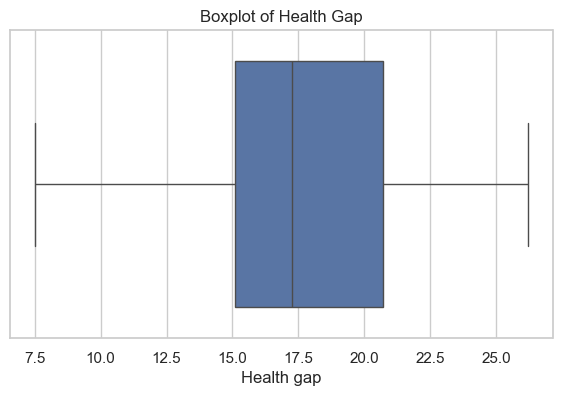

In [7]:
# boxplot of healthgap across countries with mean 
plt.figure(figsize=(7, 4))
sns.boxplot(x=eda_df["health_gap"])
plt.xlabel("Health gap")
plt.title("Boxplot of Health Gap")
plt.show()

In [8]:
# Make country_gap to plot health gap across countries
country_gap = (
    eda_df
    .groupby("geo")["health_gap"]
    .mean()
    .sort_values(ascending=False)
    .drop("EE")
)

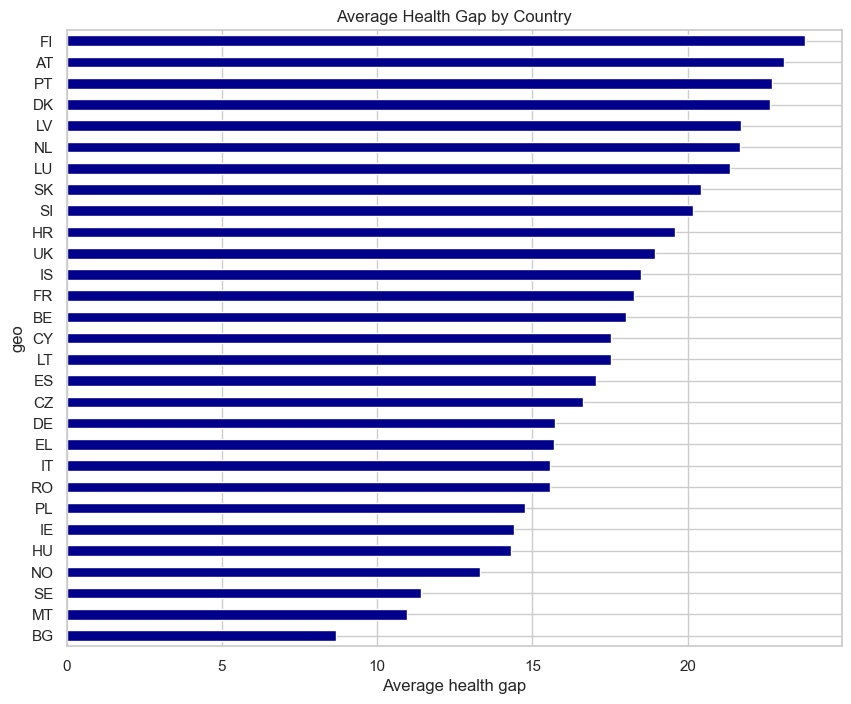

In [9]:
# Plot: Average health gap across countries 
plt.figure(figsize=(10, 8))
country_gap.sort_values().plot(kind="barh", color = "darkblue")
plt.xlabel("Average health gap")
plt.title("Average Health Gap by Country")

plt.show()

### Average european trend over time

In [10]:
yearly_gap = (
    eda_df
    .groupby("year")["health_gap"]
    .mean()
)

yearly_hly = (
    eda_df
    .groupby("year")["healthy_life_years"]
    .mean()
)

yearly_life = (
    eda_df
    .groupby("year")["life_expectancy"]
    .mean()
)

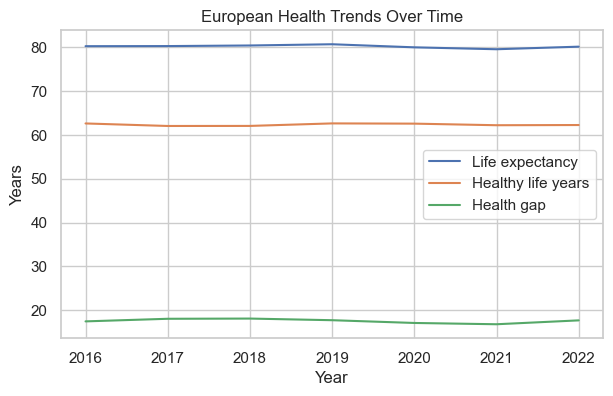

In [11]:
plt.figure(figsize=(7, 4))

plt.plot(yearly_life.index, yearly_life.values,
         label="Life expectancy")

plt.plot(yearly_hly.index, yearly_hly.values,
         label="Healthy life years")

plt.plot(yearly_gap.index, yearly_gap.values,
         label="Health gap")

plt.xlabel("Year")
plt.ylabel("Years")
plt.title("European Health Trends Over Time")

plt.legend()
plt.show()

In [12]:
top_gap = country_gap.head(5).index
low_gap = country_gap.tail(5).index

selected = list(top_gap) + list(low_gap)

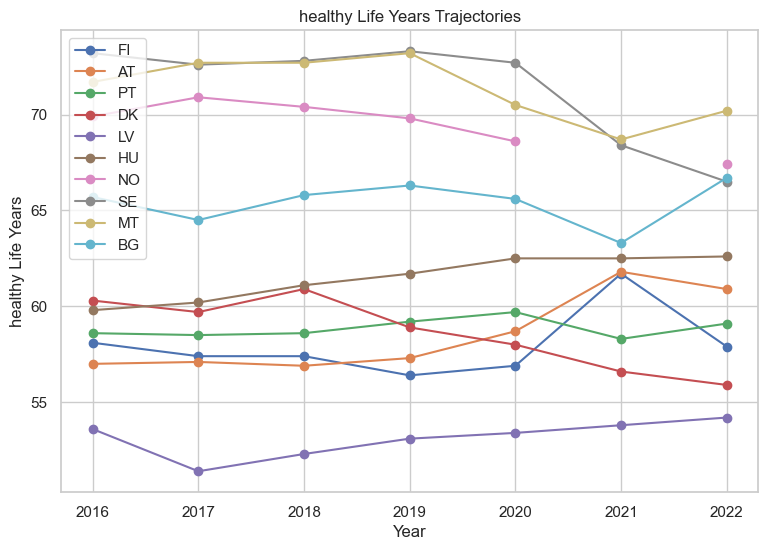

In [13]:
plt.figure(figsize=(9, 6))

for country in selected:
    
    subset = eda_df[eda_df["geo"] == country]
    
    plt.plot(
        subset["year"],
        subset["healthy_life_years"],
        marker="o",
        label=country
    )

plt.xlabel("Year")
plt.ylabel("healthy Life Years")
plt.title("healthy Life Years Trajectories")

plt.legend()
plt.show()

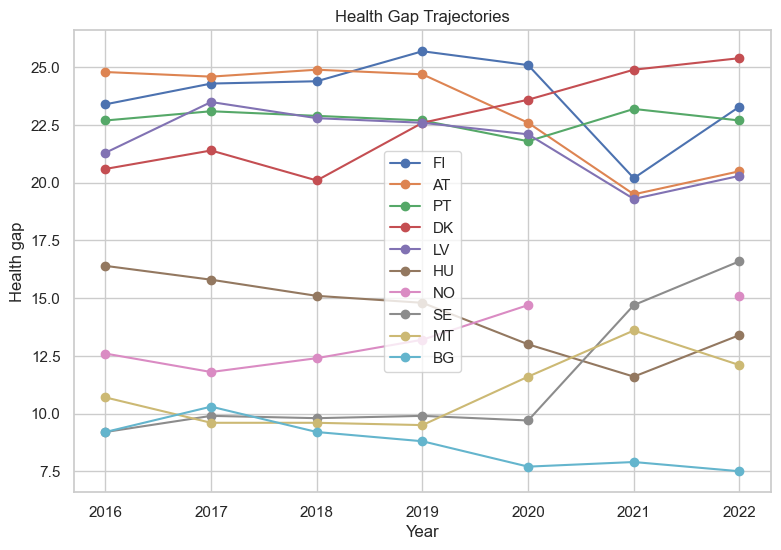

In [14]:
plt.figure(figsize=(9, 6))

for country in selected:
    
    subset = eda_df[eda_df["geo"] == country]
    
    plt.plot(
        subset["year"],
        subset["health_gap"],
        marker="o",
        label=country
    )

plt.xlabel("Year")
plt.ylabel("Health gap")
plt.title("Health Gap Trajectories")

plt.legend()
plt.show()

### Create Covid-19 period

In [15]:
eda_df["covid_period"] = (eda_df["year"] >= 2020).astype(int)

## Correlation and Relationships

In [16]:
corr_cols = [
    "health_gap",
    "healthy_life_years",
    "health_exp",
    "gdp",
    "smokers",
    "med_att",
    "perc_health",
    "antibiotics_DD",
    "overweight_pct",
    "above_65",
    "pm25_deaths"
]

corr = eda_df[corr_cols].corr()

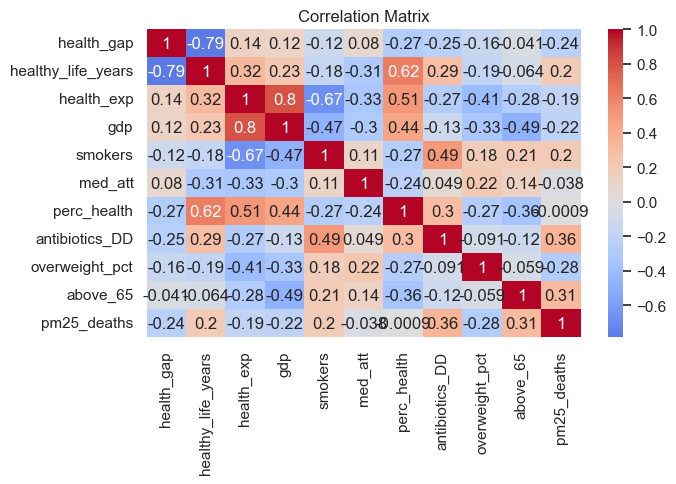

In [17]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [18]:
eda_df["log_gdp"] = np.log(eda_df["gdp"])

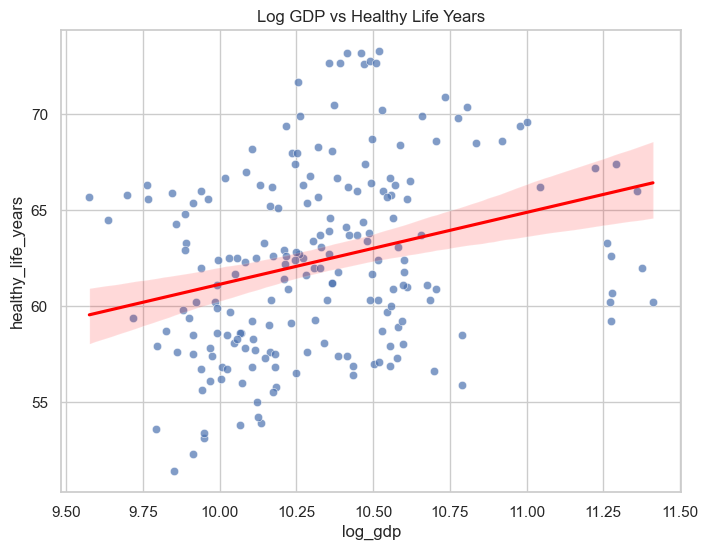

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=eda_df,
    x="log_gdp",
    y="healthy_life_years",
    alpha=0.7
)

sns.regplot(
    data=eda_df,
    x="log_gdp",
    y="healthy_life_years",
    scatter=False,
    color="red"
)

plt.title("Log GDP vs Healthy Life Years")

plt.show()

# Clustering

In [20]:
country_avg = eda_df.groupby("geo")[[
    "healthy_life_years",
    "health_gap",
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "gdp",
    "pm25_deaths"
]].mean().reset_index()

In [21]:
cluster_cols = [
    "healthy_life_years",
    "health_gap",
    "perc_health",
    "overweight_pct",
    "smokers",
    "above_65",
    "health_exp",
    "gdp",
    "pm25_deaths"
]

country_avg_clean = country_avg.dropna().copy()

X = country_avg_clean[cluster_cols]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
X_clean = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)


inertia = []

K = range(1, 10)

for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

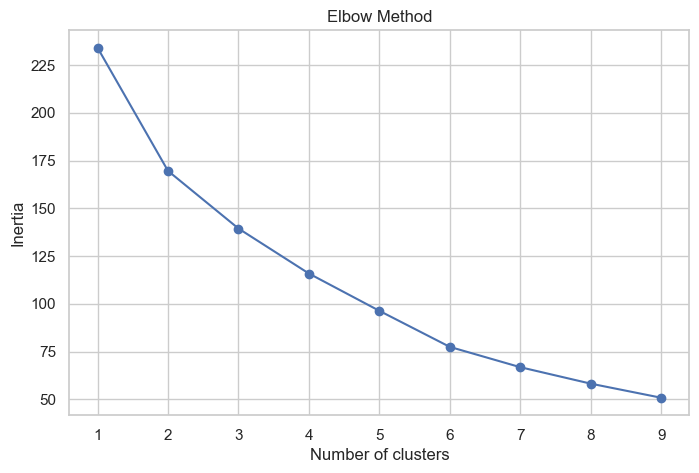

In [23]:
# Elbow plot

plt.figure(figsize=(8, 5))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [24]:
cluster_df = (
    country_avg[["geo"] + cluster_cols]
    .dropna()
    .reset_index(drop=True)
)

cluster_df.head()

,geo,healthy_life_years,health_gap,perc_health,overweight_pct,smokers,above_65,health_exp,gdp,pm25_deaths
0,AT,58.528571,23.085714,71.442857,51.557143,26.285714,18.857143,4849.314286,39031.600000,3777.000000
1,BE,63.614286,18.014286,74.985714,49.200000,20.142857,18.885714,4579.712857,36812.071429,4892.428571
2,BG,65.414286,8.657143,66.957143,56.064286,37.142857,22.357143,733.638571,17580.585714,10583.714286
3,CY,64.671429,17.528571,77.300000,50.435714,28.000000,16.142857,1955.132857,28381.614286,579.142857
4,CZ,62.114286,16.614286,63.657143,59.821429,29.571429,19.557143,1706.454286,29037.028571,8081.428571


In [25]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_df[cluster_cols]
)

In [26]:
# inspect clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

In [27]:
cluster_summary = (
    cluster_df
    .groupby("cluster")[cluster_cols]
    .mean()
    .round(2)
)

cluster_summary

,healthy_life_years,health_gap,perc_health,overweight_pct,smokers,above_65,health_exp,gdp,pm25_deaths
cluster,,,,,,,,,
0,59.67,17.46,60.11,57.78,29.38,19.66,1240.74,23281.47,9614.52
1,59.99,21.76,71.97,51.81,19.67,18.79,4938.45,45567.33,2755.55
2,70.22,12.25,77.33,57.54,15.71,17.50,4308.35,44731.74,412.71
3,65.60,16.64,72.03,50.36,28.71,20.31,2950.57,29728.58,22483.98


In [28]:
# PCA 

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

cluster_df["pca1"] = X_pca[:, 0]
cluster_df["pca2"] = X_pca[:, 1]

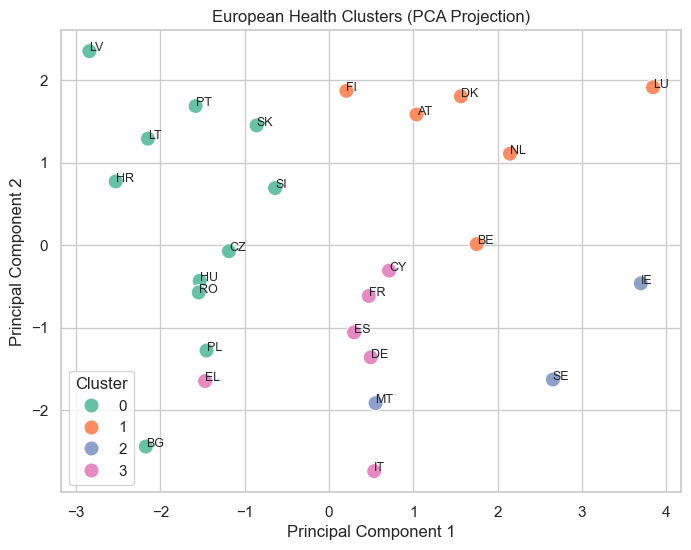

In [29]:
# plot PCA for inspection 

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=cluster_df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="Set2",
    s=120
)

for _, row in cluster_df.iterrows():
    
    plt.text(
        row["pca1"],
        row["pca2"],
        row["geo"],
        fontsize=9
    )

plt.title("European Health Clusters (PCA Projection)")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()